In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("/content/Dataset for Data Analytics (2).xlsx")

print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

DATASET INFORMATION

First 5 Rows
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Ref

In [3]:
print("\nMissing Values")
print(df.isnull().sum())

# Fill missing CouponCode values
if "CouponCode" in df.columns:
    df["CouponCode"] = df["CouponCode"].fillna("No Coupon")



Missing Values
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [4]:
# Remove duplicate rows
df = df.drop_duplicates()

print("\nDuplicates Removed Successfully!")


Duplicates Removed Successfully!


In [5]:
df.to_excel("cleaned_dataset.xlsx", index=False)

print("\nCleaned dataset saved successfully!")



Cleaned dataset saved successfully!


In [6]:
print("\nDescriptive Statistics")
print(df.describe())



Descriptive Statistics
                      Date     Quantity    UnitPrice  ItemsInCart   TotalPrice
count                 1200  1200.000000  1200.000000  1200.000000  1200.000000
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000  1053.968300
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000    11.390000
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   410.520000
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000   823.615000
75%    2024-11-08 12:00:00     4.000000   521.570000     7.000000  1578.475000
max    2025-06-30 00:00:00     5.000000   699.930000    10.000000  3456.400000
std                    NaN     1.407557   197.177146     2.281983   819.856558


In [7]:
numeric_columns = df.select_dtypes(include="number").columns

print("\nMean")
print(df[numeric_columns].mean())

print("\nMedian")
print(df[numeric_columns].median())

print("\nMode")
print(df[numeric_columns].mode().iloc[0])



Mean
Quantity          2.945833
UnitPrice       356.412750
ItemsInCart       5.485000
TotalPrice     1053.968300
dtype: float64

Median
Quantity         3.000
UnitPrice      364.210
ItemsInCart      5.000
TotalPrice     823.615
dtype: float64

Mode
Quantity         1.00
UnitPrice      127.18
ItemsInCart      5.00
TotalPrice     211.14
Name: 0, dtype: float64


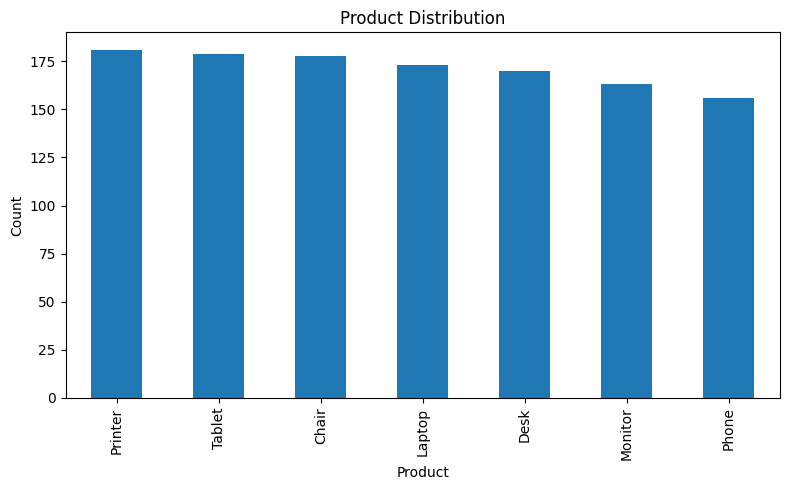

In [8]:
plt.figure(figsize=(8,5))
df["Product"].value_counts().plot(kind="bar")
plt.title("Product Distribution")
plt.xlabel("Product")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("product_distribution.png")
plt.show()

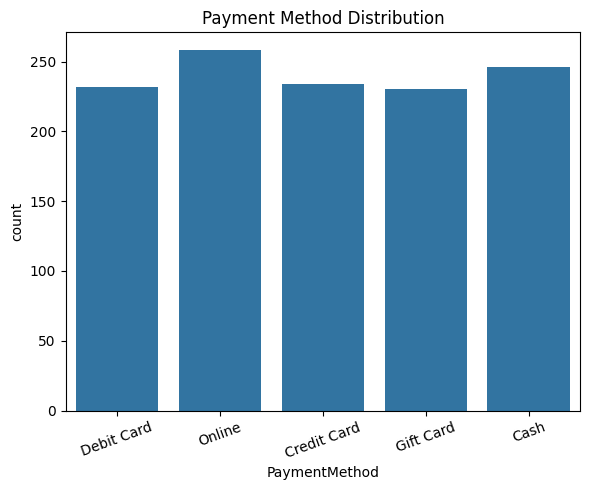

In [9]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="PaymentMethod")
plt.title("Payment Method Distribution")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("payment_method.png")
plt.show()

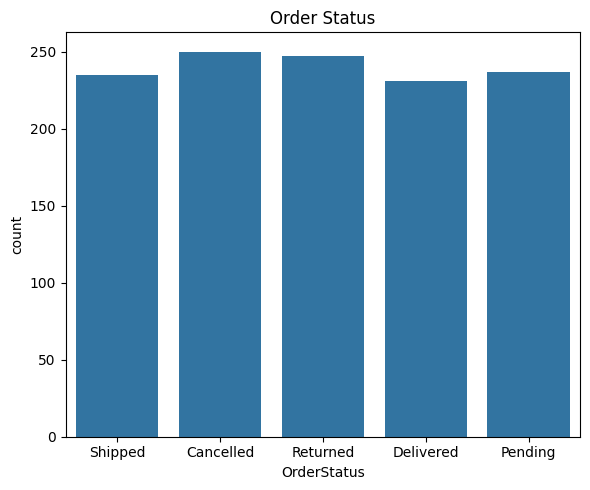

In [10]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="OrderStatus")
plt.title("Order Status")
plt.tight_layout()
plt.savefig("order_status.png")
plt.show()


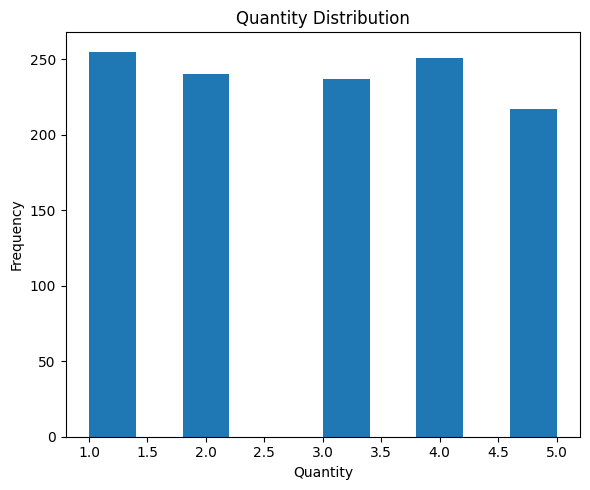

In [11]:
plt.figure(figsize=(6,5))
plt.hist(df["Quantity"], bins=10)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("quantity_histogram.png")
plt.show()


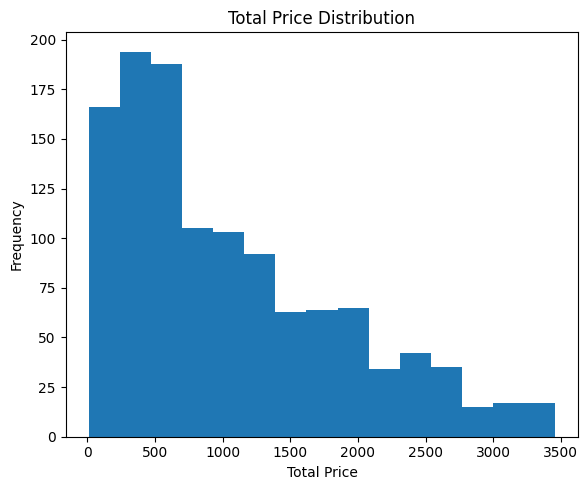

In [12]:
plt.figure(figsize=(6,5))
plt.hist(df["TotalPrice"], bins=15)
plt.title("Total Price Distribution")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("totalprice_histogram.png")
plt.show()


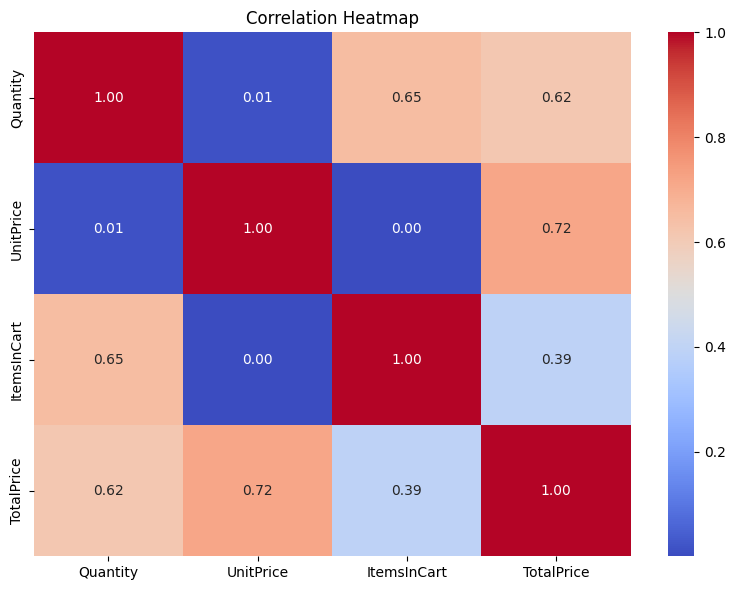

In [13]:
plt.figure(figsize=(8,6))

corr = df[numeric_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()


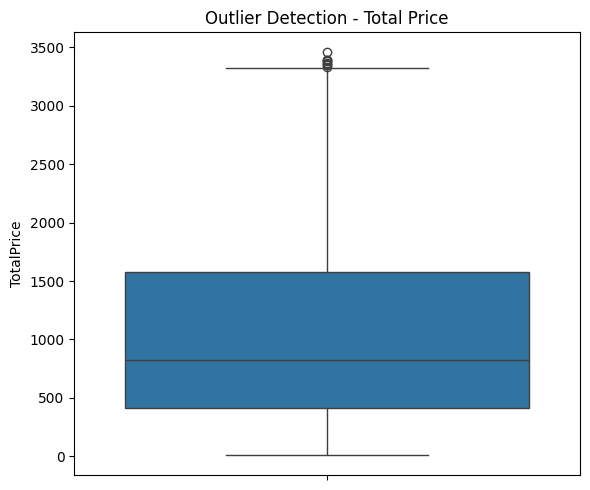

In [14]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df["TotalPrice"])
plt.title("Outlier Detection - Total Price")
plt.tight_layout()
plt.savefig("boxplot_totalprice.png")
plt.show()


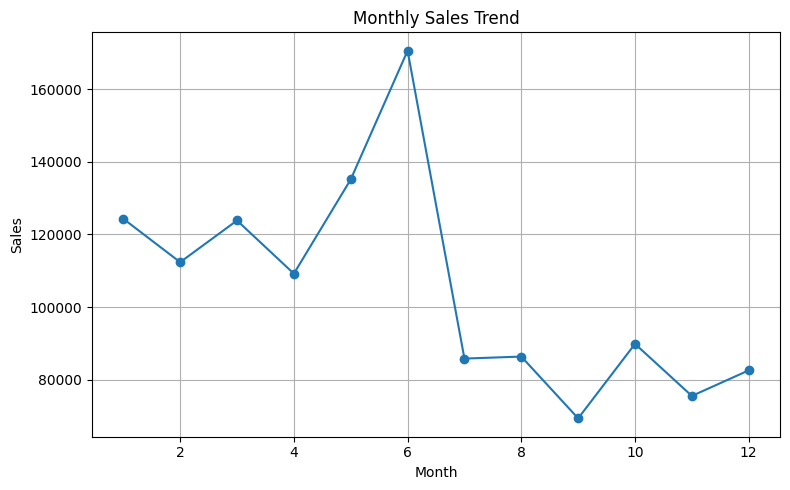

In [15]:
df["Date"] = pd.to_datetime(df["Date"])

monthly_sales = df.groupby(df["Date"].dt.month)["TotalPrice"].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.savefig("monthly_sales.png")
plt.show()

In [16]:
print("\nTop Selling Products")
print(df["Product"].value_counts())


Top Selling Products
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64


In [17]:
print("\nPayment Method Counts")
print(df["PaymentMethod"].value_counts())


Payment Method Counts
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


In [18]:
print("\nOrder Status Counts")
print(df["OrderStatus"].value_counts())


Order Status Counts
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


In [19]:
print("\n==============================")
print("BUSINESS INSIGHTS")
print("==============================")

print(f"Total Orders : {len(df)}")

print(f"Average Order Value : {df['TotalPrice'].mean():.2f}")

print(f"Highest Order Value : {df['TotalPrice'].max():.2f}")

print(f"Lowest Order Value : {df['TotalPrice'].min():.2f}")

print("Most Sold Product :")
print(df["Product"].value_counts().idxmax())

print("Most Preferred Payment Method :")
print(df["PaymentMethod"].value_counts().idxmax())

print("Most Common Order Status :")
print(df["OrderStatus"].value_counts().idxmax())

print("\nEDA Completed Successfully!")


BUSINESS INSIGHTS
Total Orders : 1200
Average Order Value : 1053.97
Highest Order Value : 3456.40
Lowest Order Value : 11.39
Most Sold Product :
Printer
Most Preferred Payment Method :
Online
Most Common Order Status :
Cancelled

EDA Completed Successfully!
